In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, explode, split, expr
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.clustering import KMeans

from pyspark.sql.functions import col
from pyspark.ml.clustering import KMeans

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import warnings

from pyspark.ml.recommendation import ALSModel

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("\nAll libraries imported successfully!")


All libraries imported successfully!


In [3]:
spark = SparkSession.builder \
    .appName("MovieLens Recommender System") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

# Set log level to reduce output
spark.sparkContext.setLogLevel("WARN")
spark.conf.set("fs.defaultFS", "gs://dsa5101-proj-bucket")

print(f"Spark Session created successfully!")
print(f"Spark Version: {spark.version}")
print(f"Driver Memory: 8GB")
print(f"Executor Memory: 8GB")
print(f"Application Name: {spark.sparkContext.appName}")

Spark Session created successfully!
Spark Version: 3.5.3
Driver Memory: 8GB
Executor Memory: 8GB
Application Name: PySparkShell


In [4]:
def load_data(ratings_path='gs://dsa5101-proj-bucket/rating.csv', movies_path='gs://dsa5101-proj-bucket/movies.csv'):
    print(f"\nLoading ratings from: {ratings_path}")
    ratings_df = spark.read.csv(
        ratings_path,
        header=True,
        inferSchema=True
    )

    print(f"Loading movies from: {movies_path}")
    movies_df = spark.read.csv(
        movies_path,
        header=True,
        inferSchema=True
    )

    print("\nData loaded successfully!")
    return ratings_df, movies_df


# Load the data
ratings_df, movies_df = load_data('rating.csv', 'movie.csv')

print("SAMPLE RATINGS (5 rows):")
ratings_df.show(5, truncate=False)

print("SAMPLE MOVIES (5 rows):")
movies_df.show(5, truncate=False)

print("\nData preview complete!")


Loading ratings from: rating.csv


Loading movies from: movie.csv

Data loaded successfully!
SAMPLE RATINGS (5 rows):
+------+-------+------+-------------------+
|userId|movieId|rating|timestamp          |
+------+-------+------+-------------------+
|1     |2      |3.5   |2005-04-02 23:53:47|
|1     |29     |3.5   |2005-04-02 23:31:16|
|1     |32     |3.5   |2005-04-02 23:33:39|
|1     |47     |3.5   |2005-04-02 23:32:07|
|1     |50     |3.5   |2005-04-02 23:29:40|
+------+-------+------+-------------------+
only showing top 5 rows

SAMPLE MOVIES (5 rows):
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (

# This is to load previous saved data

In [ ]:
# Load filtered ratings
filtered_ratings = spark.read.parquet("filtered_ratings.parquet")

# Load train/test split
train_df = spark.read.parquet("train_df.parquet")
test_df = spark.read.parquet("test_df.parquet")

# Load ALS model
model = ALSModel.load("als_model")

# Load factors
user_factors = spark.read.parquet("user_factors.parquet")
item_factors = spark.read.parquet("item_factors.parquet")

# Recreate stats dictionary
stats = {
    'num_ratings': filtered_ratings.count(),
    'num_users': filtered_ratings.select('userId').distinct().count(),
    'num_movies': filtered_ratings.select('movieId').distinct().count(),
}

rmse = 0.8110  
mae = 0.6349   

print("\nALL DATA LOADED! You can now skip to Cell 12 (clustering)")

LOADING SAVED DATA FROM PARQUET (ONLY RUN IF KERNEL DIES)


Filtered ratings loaded



[Stage 7:>                                                          (0 + 1) / 1]



Train/test data loaded


ALS model loaded
Factors loaded


Stats recreated

ALL DATA LOADED! You can now skip to Cell 12 (clustering)


In [5]:
def compute_statistics(ratings_df, movies_df):

    # Basic counts
    num_ratings = ratings_df.count()
    num_users = ratings_df.select('userId').distinct().count()
    num_movies = ratings_df.select('movieId').distinct().count()

    print("Counts computed")

    # Rating statistics
    rating_stats = ratings_df.select(
        avg('rating').alias('avg_rating'),
        expr('min(rating)').alias('min_rating'),
        expr('max(rating)').alias('max_rating')
    ).collect()[0]

    # Sparsity
    sparsity = 1.0 - (num_ratings / (num_users * num_movies))

    print("DATASET OVERVIEW")
    print(f"{'Metric':<30} {'Value':>20}")
    print(f"{'Total Ratings':<30} {num_ratings:>20,}")
    print(f"{'Unique Users':<30} {num_users:>20,}")
    print(f"{'Unique Movies':<30} {num_movies:>20,}")
    print(f"{'Average Rating':<30} {rating_stats['avg_rating']:>20.2f}")
    print(f"{'Min Rating':<30} {rating_stats['min_rating']:>20.1f}")
    print(f"{'Max Rating':<30} {rating_stats['max_rating']:>20.1f}")
    print(f"{'Sparsity':<30} {sparsity * 100:>19.2f}%")

    print("\nComputing ratings per user")
    # Ratings per user
    ratings_per_user = ratings_df.groupBy('userId').count().select('count')
    user_stats = ratings_per_user.summary('mean', 'min', 'max', '25%', '50%', '75%')

    print("RATINGS PER USER STATISTICS:")
    user_stats.show()

    print("Computing ratings per movie")
    # Ratings per movie
    ratings_per_movie = ratings_df.groupBy('movieId').count().select('count')
    movie_stats = ratings_per_movie.summary('mean', 'min', 'max', '25%', '50%', '75%')

    print("RATINGS PER MOVIE STATISTICS:")
    movie_stats.show()

    print("\nAll statistics computed successfully!")

    return {
        'num_ratings': num_ratings,
        'num_users': num_users,
        'num_movies': num_movies,
        'sparsity': sparsity,
        'avg_rating': rating_stats['avg_rating']
    }


stats = compute_statistics(ratings_df, movies_df)

print("\nStatistics stored in 'stats' dictionary")

Counts computed


DATASET OVERVIEW
Metric                                        Value
Total Ratings                            20,000,263
Unique Users                                138,493
Unique Movies                                26,744
Average Rating                                 3.53
Min Rating                                      0.5
Max Rating                                      5.0
Sparsity                                     99.46%

Computing ratings per user
RATINGS PER USER STATISTICS:


+-------+-----------------+
|summary|            count|
+-------+-----------------+
|   mean|144.4135299257002|
|    min|               20|
|    max|             9254|
|    25%|               35|
|    50%|               68|
|    75%|              155|
+-------+-----------------+

Computing ratings per movie
RATINGS PER MOVIE STATISTICS:


+-------+-----------------+
|summary|            count|
+-------+-----------------+
|   mean|747.8411232425965|
|    min|                1|
|    max|            67310|
|    25%|                3|
|    50%|               18|
|    75%|              205|
+-------+-----------------+


All statistics computed successfully!

Statistics stored in 'stats' dictionary


Sampling 0.5% of data (100,000 ratings)



Data prepared
Plot 1/6: Rating distribution
Plot 2/6: Ratings per user


Plot 3/6: Ratings per movie


Plot 4/6: Average rating per movie


Plot 5/6: Rating trends over time
Plot 6/6: Genre distribution

Figure saved as: dataset_exploration.png


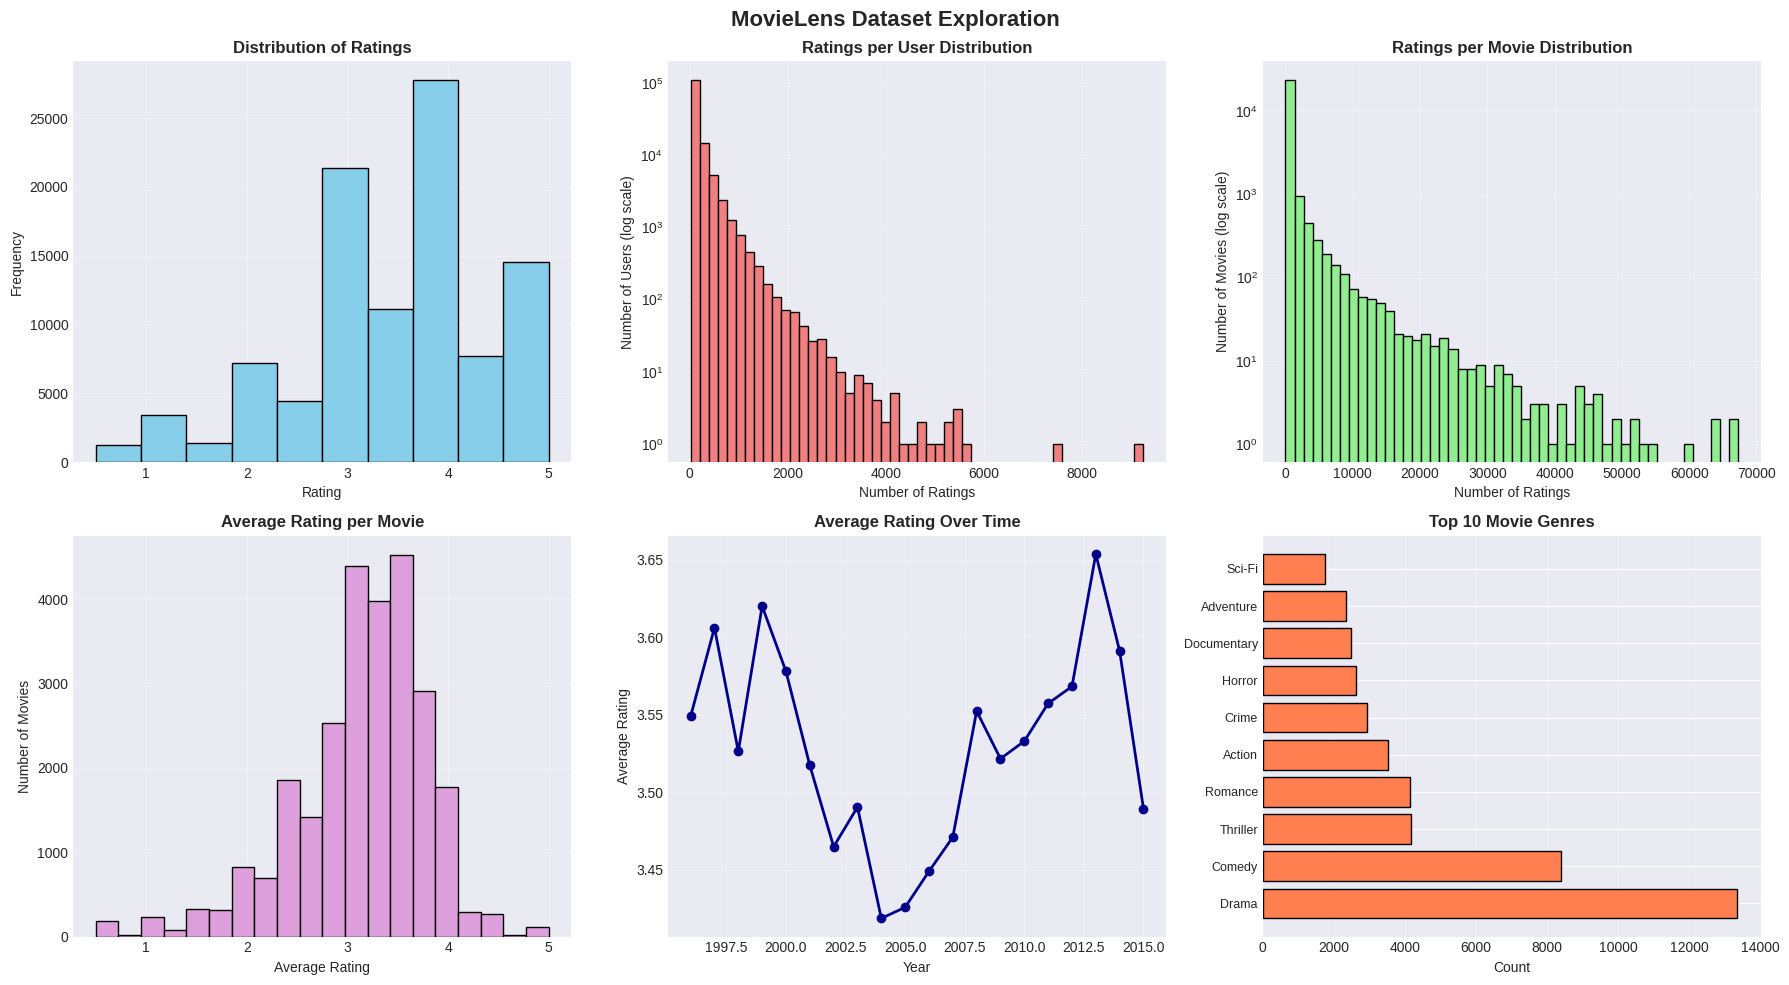

All visualizations created successfully!


In [6]:
def visualize_dataset(ratings_df, movies_df):

    # Sample data for efficiency (adjust based on your dataset size)
    sample_size = 100000
    total_ratings = ratings_df.count()
    sample_fraction = min(sample_size / total_ratings, 1.0)

    print(f"Sampling {sample_fraction * 100:.1f}% of data ({min(sample_size, total_ratings):,} ratings)")
    ratings_sample = ratings_df.sample(False, sample_fraction, seed=42)

    # Convert to Pandas
    ratings_pd = ratings_sample.toPandas()

    print("\nData prepared")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('MovieLens Dataset Exploration', fontsize=16, fontweight='bold')

    # 1. Distribution of ratings
    print("Plot 1/6: Rating distribution")
    axes[0, 0].hist(ratings_pd['rating'], bins=10, edgecolor='black', color='skyblue')
    axes[0, 0].set_xlabel('Rating', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].set_title('Distribution of Ratings', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Ratings per user
    print("Plot 2/6: Ratings per user")
    ratings_per_user = ratings_df.groupBy('userId').count().toPandas()
    axes[0, 1].hist(ratings_per_user['count'], bins=50, edgecolor='black', color='lightcoral')
    axes[0, 1].set_xlabel('Number of Ratings', fontsize=10)
    axes[0, 1].set_ylabel('Number of Users (log scale)', fontsize=10)
    axes[0, 1].set_title('Ratings per User Distribution', fontweight='bold')
    axes[0, 1].set_yscale('log')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Ratings per movie
    print("Plot 3/6: Ratings per movie")
    ratings_per_movie = ratings_df.groupBy('movieId').count().toPandas()
    axes[0, 2].hist(ratings_per_movie['count'], bins=50, edgecolor='black', color='lightgreen')
    axes[0, 2].set_xlabel('Number of Ratings', fontsize=10)
    axes[0, 2].set_ylabel('Number of Movies (log scale)', fontsize=10)
    axes[0, 2].set_title('Ratings per Movie Distribution', fontweight='bold')
    axes[0, 2].set_yscale('log')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Average rating distribution
    print("Plot 4/6: Average rating per movie")
    avg_ratings = ratings_df.groupBy('movieId').agg(avg('rating').alias('avg_rating')).toPandas()
    axes[1, 0].hist(avg_ratings['avg_rating'], bins=20, edgecolor='black', color='plum')
    axes[1, 0].set_xlabel('Average Rating', fontsize=10)
    axes[1, 0].set_ylabel('Number of Movies', fontsize=10)
    axes[1, 0].set_title('Average Rating per Movie', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Rating trends over time (if timestamp available)
    print("Plot 5/6: Rating trends over time")
    if 'timestamp' in ratings_pd.columns:
        ratings_pd['year'] = pd.to_datetime(ratings_pd['timestamp'], unit='s').dt.year
        yearly_avg = ratings_pd.groupby('year')['rating'].mean()
        axes[1, 1].plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2, markersize=6, color='darkblue')
        axes[1, 1].set_xlabel('Year', fontsize=10)
        axes[1, 1].set_ylabel('Average Rating', fontsize=10)
        axes[1, 1].set_title('Average Rating Over Time', fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'Timestamp not available', ha='center', va='center', fontsize=12)
        axes[1, 1].set_title('Rating Trends (N/A)', fontweight='bold')

    # 6. Genre distribution
    print("Plot 6/6: Genre distribution")
    if movies_df is not None:
        movies_pd = movies_df.toPandas()
        if 'genres' in movies_pd.columns:
            genres = movies_pd['genres'].str.split('|').explode()
            genre_counts = genres.value_counts().head(10)
            axes[1, 2].barh(range(len(genre_counts)), genre_counts.values, color='coral', edgecolor='black')
            axes[1, 2].set_yticks(range(len(genre_counts)))
            axes[1, 2].set_yticklabels(genre_counts.index, fontsize=9)
            axes[1, 2].set_xlabel('Count', fontsize=10)
            axes[1, 2].set_title('Top 10 Movie Genres', fontweight='bold')
            axes[1, 2].grid(True, alpha=0.3, axis='x')
        else:
            axes[1, 2].text(0.5, 0.5, 'Genre data not available', ha='center', va='center', fontsize=12)

    plt.tight_layout()
    plt.savefig('dataset_exploration.png', dpi=300, bbox_inches='tight')
    print("\nFigure saved as: dataset_exploration.png")
    plt.show()

    print("All visualizations created successfully!")


visualize_dataset(ratings_df, movies_df)

In [8]:
def preprocess_data(ratings_df, min_ratings_per_user=20, min_ratings_per_movie=20):
    print(f"\nFiltering criteria:")
    print(f"Minimum ratings per user: {min_ratings_per_user}")
    print(f"Minimum ratings per movie: {min_ratings_per_movie}")

    initial_count = ratings_df.count()
    initial_users = ratings_df.select('userId').distinct().count()
    initial_movies = ratings_df.select('movieId').distinct().count()

    print(f"Ratings: {initial_count:,}")
    print(f"Users: {initial_users:,}")
    print(f"Movies: {initial_movies:,}")

    # Count ratings per user and movie
    user_counts = ratings_df.groupBy('userId').count()
    movie_counts = ratings_df.groupBy('movieId').count()

    # Filter active users and popular movies
    active_users = user_counts.filter(col('count') >= min_ratings_per_user).select('userId')
    print(f"Found {active_users.count():,} active users")

    popular_movies = movie_counts.filter(col('count') >= min_ratings_per_movie).select('movieId')
    print(f"Found {popular_movies.count():,} popular movies")

    # Join to filter ratings
    filtered_ratings = ratings_df \
        .join(active_users, on='userId', how='inner') \
        .join(popular_movies, on='movieId', how='inner')

    final_count = filtered_ratings.count()
    final_users = filtered_ratings.select('userId').distinct().count()
    final_movies = filtered_ratings.select('movieId').distinct().count()

    print("PREPROCESSING RESULTS")
    print(f"{'Metric':<20} {'Before':>15} {'After':>15} {'Change':>15}")
    print(f"{'Ratings':<20} {initial_count:>15,} {final_count:>15,} {final_count - initial_count:>15,}")
    print(f"{'Users':<20} {initial_users:>15,} {final_users:>15,} {final_users - initial_users:>15,}")
    print(f"{'Movies':<20} {initial_movies:>15,} {final_movies:>15,} {final_movies - initial_movies:>15,}")
    print(f"Retention rate: {final_count / initial_count * 100:.1f}%")

    return filtered_ratings

filtered_ratings = preprocess_data(ratings_df, min_ratings_per_user=20, min_ratings_per_movie=20)

print("\nFiltered data stored in 'filtered_ratings'")


Filtering criteria:
Minimum ratings per user: 20
Minimum ratings per movie: 20


Ratings: 20,000,263
Users: 138,493
Movies: 26,744


Found 138,493 active users


Found 13,132 popular movies


PREPROCESSING RESULTS
Metric                        Before           After          Change
Ratings                   20,000,263      19,933,089         -67,174
Users                        138,493         138,493               0
Movies                        26,744          13,132         -13,612
Retention rate: 99.7%

Filtered data stored in 'filtered_ratings'



[Stage 168:============================>                            (2 + 2) / 4]



In [9]:
def split_data(ratings_df, train_ratio=0.7, seed=42):
    print(f"\nSplit configuration:")
    print(f"Train ratio: {train_ratio * 100:.0f}%")
    print(f"Test ratio: {(1 - train_ratio) * 100:.0f}%")
    print(f"Random seed: {seed}")

    print("\nPerforming split")
    train_df, test_df = ratings_df.randomSplit([train_ratio, 1 - train_ratio], seed=seed)

    train_count = train_df.count()
    test_count = test_df.count()
    total = train_count + test_count

    print("TRAIN-TEST SPLIT RESULTS")
    print(f"{'Set':<15} {'Count':>15} {'Percentage':>15}")
    print(f"{'Train':<15} {train_count:>15,} {train_count / total * 100:>14.1f}%")
    print(f"{'Test':<15} {test_count:>15,} {test_count / total * 100:>14.1f}%")
    print(f"{'Total':<15} {total:>15,} {100.0:>14.1f}%")
    print("\nSplit complete!")
    return train_df, test_df


train_df, test_df = split_data(filtered_ratings, train_ratio=0.7, seed=42)

print("\nTraining data stored in 'train_df'")
print("Test data stored in 'test_df'")


Split configuration:
Train ratio: 70%
Test ratio: 30%
Random seed: 42

Performing split


TRAIN-TEST SPLIT RESULTS
Set                       Count      Percentage
Train                13,954,458           70.0%
Test                  5,978,631           30.0%
Total                19,933,089          100.0%

Split complete!

Training data stored in 'train_df'
Test data stored in 'test_df'


In [11]:
def train_als_model(train_df, rank=50, maxIter=10, regParam=0.1):
    print(f"\nModel Configuration:")
    print(f"Rank (latent factors): {rank}")
    print(f"Max iterations: {maxIter}")
    print(f"Regularization parameter: {regParam}")
    print(f"Cold start strategy: drop")

    print("\nInitializing ALS model")
    als = ALS(
        rank=rank,
        maxIter=maxIter,
        regParam=regParam,
        userCol="userId",
        itemCol="movieId",
        ratingCol="rating",
        coldStartStrategy="drop",
        seed=42
    )

    print("Training model")
    import time
    start_time = time.time()

    model = als.fit(train_df)

    elapsed_time = time.time() - start_time

    print(f"\nALS model trained successfully!")
    print(f"Training time: {elapsed_time:.2f} seconds ({elapsed_time / 60:.2f} minutes)")

    # Display model info
    print(f"\nModel Details:")
    print(f"User factors: {model.userFactors.count():,}")
    print(f"Item factors: {model.itemFactors.count():,}")
    print(f"Rank: {model.rank}")

    return model


model = train_als_model(train_df, rank=50, maxIter=10, regParam=0.1)

print("\nModel stored in 'model' variable")


Model Configuration:
Rank (latent factors): 50
Max iterations: 10
Regularization parameter: 0.1
Cold start strategy: drop

Initializing ALS model
Training model



ALS model trained successfully!
Training time: 194.19 seconds (3.24 minutes)

Model Details:
User factors: 138,493
Item factors: 13,132
Rank: 50

Model stored in 'model' variable


In [13]:
def evaluate_model(model, test_df, metric='rmse'):
    print(f"\nEvaluating model using {metric.upper()}...")

    print("Making predictions on test set")
    predictions = model.transform(test_df)

    print(f"Predictions generated")
    print("\nSample predictions:")
    predictions.select('userId', 'movieId', 'rating', 'prediction').show(10, truncate=False)

    print("\nCalculating evaluation metric")
    evaluator = RegressionEvaluator(
        metricName=metric,
        labelCol="rating",
        predictionCol="prediction"
    )

    score = evaluator.evaluate(predictions)

    print(f"{metric.upper()} SCORE: {score:.4f}")

    return score, predictions


print("\nEvaluating with RMSE")
rmse, predictions = evaluate_model(model, test_df, metric='rmse')

print("\nEvaluating with MAE")
mae, _ = evaluate_model(model, test_df, metric='mae')

print("MODEL PERFORMANCE SUMMARY")
print(f"{'Metric':<20} {'Score':>15}")
print(f"{'RMSE':<20} {rmse:>15.4f}")
print(f"{'MAE':<20} {mae:>15.4f}")

print("\nEvaluation complete!")
print("Predictions stored in 'predictions' variable")


Evaluating with RMSE

Evaluating model using RMSE...
Making predictions on test set
Predictions generated

Sample predictions:


+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|1     |29     |3.5   |3.6057136 |
|1     |47     |3.5   |3.8240244 |
|1     |50     |3.5   |3.9890432 |
|1     |223    |4.0   |3.5915184 |
|1     |318    |4.0   |4.140961  |
|1     |367    |3.5   |3.1978416 |
|1     |653    |3.0   |3.4173343 |
|1     |924    |3.5   |3.5045652 |
|1     |1009   |3.5   |3.1558678 |
|1     |1079   |4.0   |3.5650094 |
+------+-------+------+----------+
only showing top 10 rows


Calculating evaluation metric


RMSE SCORE: 0.8114

Evaluating with MAE

Evaluating model using MAE...
Making predictions on test set
Predictions generated

Sample predictions:


+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|1     |29     |3.5   |3.6057136 |
|1     |47     |3.5   |3.8240244 |
|1     |50     |3.5   |3.9890432 |
|1     |223    |4.0   |3.5915184 |
|1     |318    |4.0   |4.140961  |
|1     |367    |3.5   |3.1978416 |
|1     |653    |3.0   |3.4173343 |
|1     |924    |3.5   |3.5045652 |
|1     |1009   |3.5   |3.1558678 |
|1     |1079   |4.0   |3.5650094 |
+------+-------+------+----------+
only showing top 10 rows


Calculating evaluation metric


MAE SCORE: 0.6352
MODEL PERFORMANCE SUMMARY
Metric                         Score
RMSE                          0.8114
MAE                           0.6352

Evaluation complete!
Predictions stored in 'predictions' variable



[Stage 1038:==========================================>             (3 + 1) / 4]




Hyperparameter grid:
Ranks to test: [10, 30, 50]
Reg params to test: [0.01, 0.1, 0.5]
Total combinations: 9
TUNING PROGRESS

[1/9] Testing rank=10, regParam=0.01

Model Configuration:
Rank (latent factors): 10
Max iterations: 10
Regularization parameter: 0.01
Cold start strategy: drop

Initializing ALS model
Training model



ALS model trained successfully!
Training time: 114.14 seconds (1.90 minutes)

Model Details:
User factors: 138,493
Item factors: 13,132
Rank: 10

Evaluating model using RMSE...
Making predictions on test set
Predictions generated

Sample predictions:


+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|8     |1      |4.0   |4.2407913 |
|13    |1      |4.0   |2.5750983 |
|16    |1      |3.0   |3.4031165 |
|19    |1      |5.0   |3.9442003 |
|31    |1      |3.0   |3.490079  |
|34    |1      |5.0   |4.8962164 |
|39    |1      |5.0   |4.0118666 |
|58    |1      |5.0   |4.2556734 |
|66    |1      |4.0   |3.608519  |
|80    |1      |3.0   |3.579647  |
+------+-------+------+----------+
only showing top 10 rows


Calculating evaluation metric


RMSE SCORE: 0.8112
Result: RMSE = 0.8112

[2/9] Testing rank=10, regParam=0.1

Model Configuration:
Rank (latent factors): 10
Max iterations: 10
Regularization parameter: 0.1
Cold start strategy: drop

Initializing ALS model
Training model



ALS model trained successfully!
Training time: 103.74 seconds (1.73 minutes)

Model Details:
User factors: 138,493
Item factors: 13,132
Rank: 10

Evaluating model using RMSE...
Making predictions on test set
Predictions generated

Sample predictions:


...

+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|1     |29     |3.5   |3.6057136 |
|1     |47     |3.5   |3.8240244 |
|1     |50     |3.5   |3.9890432 |
|1     |223    |4.0   |3.5915184 |
|1     |318    |4.0   |4.140961  |
|1     |367    |3.5   |3.1978414 |
|1     |653    |3.0   |3.4173343 |
|1     |924    |3.5   |3.5045652 |
|1     |1009   |3.5   |3.155868  |
|1     |1079   |4.0   |3.5650094 |
+------+-------+------+----------+
only showing top 10 rows


Calculating evaluation metric


RMSE SCORE: 0.8114
Result: RMSE = 0.8114

[9/9] Testing rank=50, regParam=0.5

Model Configuration:
Rank (latent factors): 50
Max iterations: 10
Regularization parameter: 0.5
Cold start strategy: drop

Initializing ALS model
Training model



ALS model trained successfully!
Training time: 178.75 seconds (2.98 minutes)

Model Details:
User factors: 138,493
Item factors: 13,132
Rank: 50

Evaluating model using RMSE...
Making predictions on test set
Predictions generated

Sample predictions:


+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|1     |29     |3.5   |3.4817011 |
|1     |47     |3.5   |3.5188441 |
|1     |50     |3.5   |3.7591257 |
|1     |223    |4.0   |3.3724837 |
|1     |318    |4.0   |3.838772  |
|1     |367    |3.5   |2.7779434 |
|1     |653    |3.0   |2.8177269 |
|1     |924    |3.5   |3.447588  |
|1     |1009   |3.5   |2.7752132 |
|1     |1079   |4.0   |3.369981  |
+------+-------+------+----------+
only showing top 10 rows


Calculating evaluation metric


RMSE SCORE: 0.9970
Result: RMSE = 0.9970
HYPERPARAMETER TUNING RESULTS
 rank  regParam     rmse
   10      0.10 0.810693
   30      0.10 0.810708
   10      0.01 0.811220
   50      0.10 0.811386
   30      0.01 0.854488
   50      0.01 0.873613
   50      0.50 0.997040
   30      0.50 0.997072
   10      0.50 0.997088

Best configuration:
Rank: 10
Reg param: 0.1
RMSE: 0.8107

Creating visualization
Heatmap saved as: als_hyperparameter_tuning.png


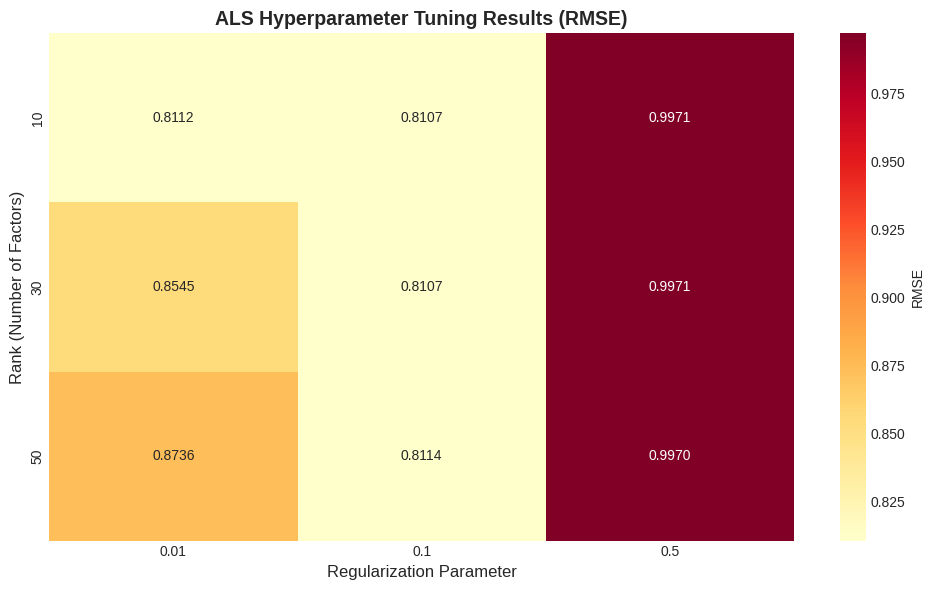


Tuning results stored in 'tuning_results'


In [14]:
def tune_als_parameters(train_df, test_df):
    print("\nHyperparameter grid:")
    ranks = [10, 30, 50]
    reg_params = [0.01, 0.1, 0.5]

    print(f"Ranks to test: {ranks}")
    print(f"Reg params to test: {reg_params}")
    print(f"Total combinations: {len(ranks) * len(reg_params)}")

    results = []
    total_combinations = len(ranks) * len(reg_params)
    current = 0

    print("TUNING PROGRESS")

    for rank in ranks:
        for reg_param in reg_params:
            current += 1
            print(f"\n[{current}/{total_combinations}] Testing rank={rank}, regParam={reg_param}")

            model = train_als_model(train_df, rank=rank, maxIter=10, regParam=reg_param)
            rmse, _ = evaluate_model(model, test_df, metric='rmse')

            results.append({
                'rank': rank,
                'regParam': reg_param,
                'rmse': rmse
            })

            print(f"Result: RMSE = {rmse:.4f}")

    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(results)

    print("HYPERPARAMETER TUNING RESULTS")
    print(results_df.sort_values('rmse').to_string(index=False))

    # Find best parameters
    best_result = results_df.loc[results_df['rmse'].idxmin()]
    print(f"\nBest configuration:")
    print(f"Rank: {int(best_result['rank'])}")
    print(f"Reg param: {best_result['regParam']}")
    print(f"RMSE: {best_result['rmse']:.4f}")

    # Visualize
    print("\nCreating visualization")
    pivot_results = results_df.pivot(index='rank', columns='regParam', values='rmse')

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_results, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'RMSE'})
    plt.title('ALS Hyperparameter Tuning Results (RMSE)', fontsize=14, fontweight='bold')
    plt.xlabel('Regularization Parameter', fontsize=12)
    plt.ylabel('Rank (Number of Factors)', fontsize=12)
    plt.tight_layout()
    plt.savefig('als_hyperparameter_tuning.png', dpi=300, bbox_inches='tight')
    print("Heatmap saved as: als_hyperparameter_tuning.png")
    plt.show()

    return results_df


tuning_results = tune_als_parameters(train_df, test_df)

print("\nTuning results stored in 'tuning_results'")

In [15]:
def extract_factors(model):
    print("\nExtracting factors from model...")

    user_factors = model.userFactors
    item_factors = model.itemFactors

    user_count = user_factors.count()
    item_count = item_factors.count()

    print(f"\nUser factors extracted: {user_count:,} users")
    print(f"Item factors extracted: {item_count:,} items")

    print("SAMPLE USER FACTORS (5 users):")
    user_factors.show(5, truncate=False)

    print("SAMPLE ITEM FACTORS (5 items):")
    item_factors.show(5, truncate=False)

    # Get factor dimensionality
    sample_features = user_factors.select('features').first()[0]
    factor_dim = len(sample_features)

    print(f"\nFactor dimensionality: {factor_dim}")
    print("Factors ready for clustering!")

    return user_factors, item_factors


user_factors, item_factors = extract_factors(model)

print("\nUser factors stored in 'user_factors'")
print("Item factors stored in 'item_factors'")


Extracting factors from model...

User factors extracted: 138,493 users
Item factors extracted: 13,132 items
SAMPLE USER FACTORS (5 users):
+---+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|id |features                                                                                                                                                                                                                      

# This is so save the data

In [23]:
GCS_BUCKET = "gs://dsa5101-proj-bucket/A0236699H_proj"

print(f"Saving to: {GCS_BUCKET}")

# Save filtered ratings
print("\nSaving filtered ratings...")
filtered_ratings.write.mode('overwrite').parquet(f"{GCS_BUCKET}/filtered_ratings.parquet")
print("Filtered ratings saved")

# Save train/test split
print("Saving train/test split...")
train_df.write.mode('overwrite').parquet(f"{GCS_BUCKET}/train_df.parquet")
test_df.write.mode('overwrite').parquet(f"{GCS_BUCKET}/test_df.parquet")
print("Train/test split saved")

# Save ALS model
print("Saving ALS model...")
model.write().overwrite().save(f"{GCS_BUCKET}/als_model")
print("ALS model saved")

# Save factors
print("Saving user/item factors...")
user_factors.write.mode('overwrite').parquet(f"{GCS_BUCKET}/user_factors.parquet")
item_factors.write.mode('overwrite').parquet(f"{GCS_BUCKET}/item_factors.parquet")
print("Factors saved")

print("\nALL DATA SAVED TO GCS!")
print(f"Location: {GCS_BUCKET}")

Saving to: gs://dsa5101-proj-bucket/A0236699H_proj

Saving filtered ratings...


Filtered ratings saved
Saving train/test split...


Train/test split saved
Saving ALS model...


ALS model saved
Saving user/item factors...


Factors saved

ALL DATA SAVED TO GCS!
Location: gs://dsa5101-proj-bucket/A0236699H_proj



Clustering configuration:
Number of clusters (k): 5
Algorithm: K-Means
Features: Latent factors from ALS

Initializing K-Means
Training K-Means model


Training complete in 15.91 seconds

Applying model to get cluster assignments...
CLUSTERING RESULTS
Within Set Sum of Squared Errors (WSSSE): 113068.92
CLUSTER DISTRIBUTION:


+-------+-----+
|cluster|count|
+-------+-----+
|      0|33554|
|      1|35285|
|      2|22886|
|      3|20166|
|      4|26602|
+-------+-----+




Creating cluster distribution visualization


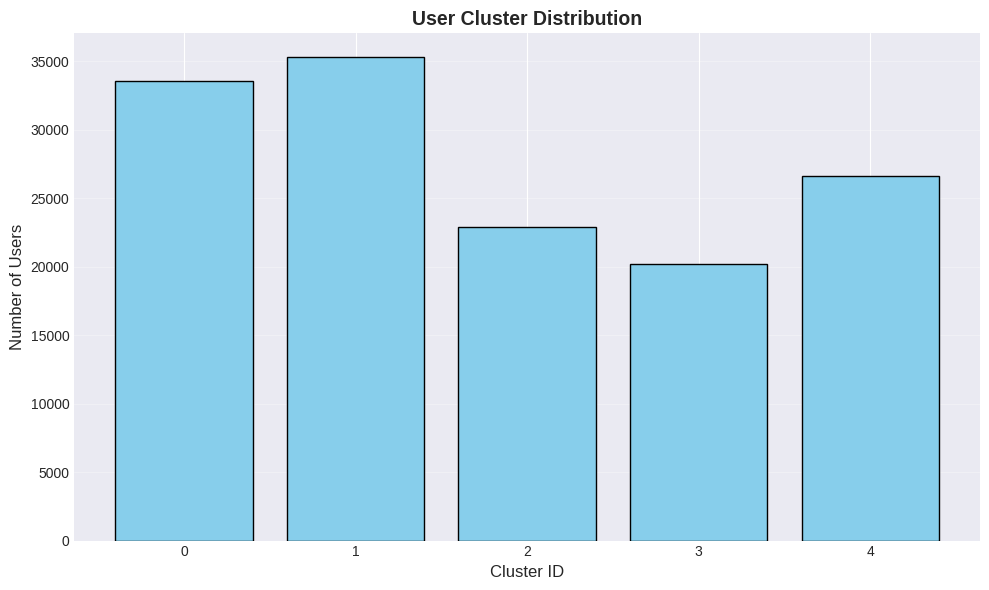


User clustering complete!

K-Means model stored in 'user_kmeans'
Clustered users stored in 'clustered_users'


In [25]:
def cluster_users(user_factors, k=5):
    print(f"\nClustering configuration:")
    print(f"Number of clusters (k): {k}")
    print(f"Algorithm: K-Means")
    print(f"Features: Latent factors from ALS")
    
    # Convert features to proper Vector type if needed
    from pyspark.ml.linalg import Vectors, VectorUDT
    from pyspark.sql.functions import udf
    from pyspark.sql.types import ArrayType, FloatType
    

    feature_type = user_factors.schema['features'].dataType # Get feature column type
    
    # If features is array<float>, convert to Vector
    if isinstance(feature_type, ArrayType):
        
        # UDF to convert array to DenseVector
        array_to_vector = udf(lambda arr: Vectors.dense(arr) if arr is not None else None, VectorUDT())
        user_factors = user_factors.withColumn('features', array_to_vector('features'))
    
    print("\nInitializing K-Means")
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol='features',
        predictionCol='cluster'
    )
    
    print("Training K-Means model")
    import time
    start_time = time.time()
    
    kmeans_model = kmeans.fit(user_factors)
    
    elapsed_time = time.time() - start_time
    print(f"Training complete in {elapsed_time:.2f} seconds")
    
    # Get cluster assignments
    print("\nApplying model to get cluster assignments...")
    clustered_users = kmeans_model.transform(user_factors)
    
    # Compute within-set sum of squared errors (WSSSE)
    wssse = kmeans_model.summary.trainingCost
    
    print("CLUSTERING RESULTS")
    print(f"Within Set Sum of Squared Errors (WSSSE): {wssse:.2f}")
    
    # Show cluster distribution
    print("CLUSTER DISTRIBUTION:")
    cluster_dist = clustered_users.groupBy('cluster').count().orderBy('cluster')
    cluster_dist.show()
    
    # Convert to pandas for visualization
    cluster_dist_pd = cluster_dist.toPandas()
    
    print("\nCreating cluster distribution visualization")
    plt.figure(figsize=(10, 6))
    plt.bar(cluster_dist_pd['cluster'], cluster_dist_pd['count'], color='skyblue', edgecolor='black')
    plt.xlabel('Cluster ID', fontsize=12)
    plt.ylabel('Number of Users', fontsize=12)
    plt.title('User Cluster Distribution', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('user_cluster_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nUser clustering complete!")
    return kmeans_model, clustered_users

user_kmeans, clustered_users = cluster_users(user_factors, k=5)

print("\nK-Means model stored in 'user_kmeans'")
print("Clustered users stored in 'clustered_users'")


Testing k values from 2 to 10...
ELBOW METHOD PROGRESS

[1/9] Testing k=2


WSSSE = 131177.72

[2/9] Testing k=3


WSSSE = 122778.17

[3/9] Testing k=4


WSSSE = 116920.59

[4/9] Testing k=5


WSSSE = 113068.92

[5/9] Testing k=6


WSSSE = 110303.93

[6/9] Testing k=7


WSSSE = 107949.79

[7/9] Testing k=8


WSSSE = 106126.96

[8/9] Testing k=9


WSSSE = 104558.10

[9/9] Testing k=10


WSSSE = 102764.04
ELBOW METHOD RESULTS
k                    WSSSE
2                131177.72
3                122778.17
4                116920.59
5                113068.92
6                110303.93
7                107949.79
8                106126.96
9                104558.10
10               102764.04

Largest improvement at k=3

Creating elbow curve visualization


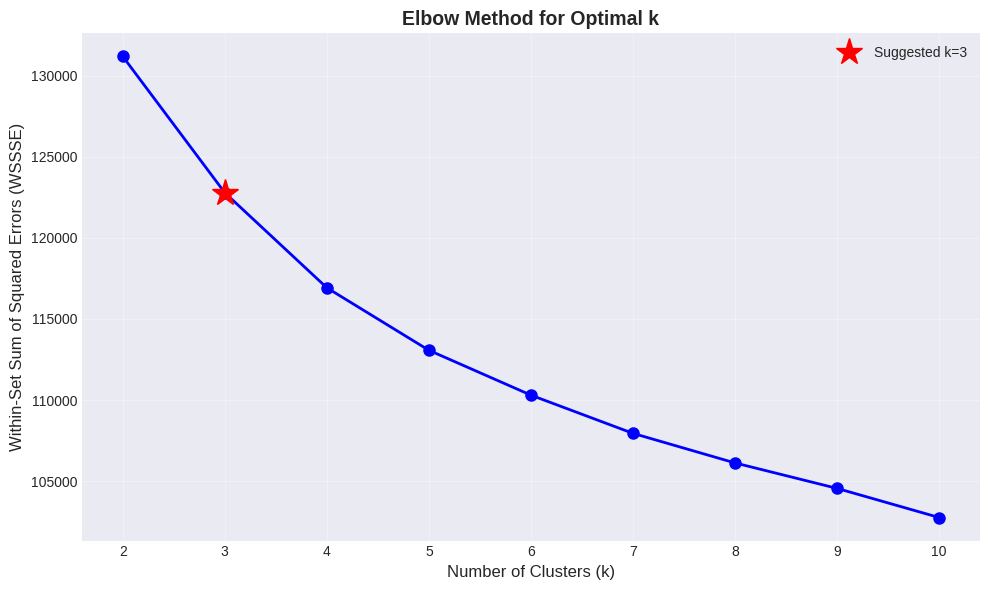


Optimal k analysis complete!

Results stored in 'k_values' and 'wssse_values'


In [26]:
def find_optimal_k(factors_df, k_range=range(2, 11)):
    print(f"\nTesting k values from {min(k_range)} to {max(k_range)}...")
    
    # Convert features to proper Vector type if needed
    from pyspark.ml.linalg import Vectors, VectorUDT
    from pyspark.sql.functions import udf
    from pyspark.sql.types import ArrayType
    
    feature_type = factors_df.schema['features'].dataType
    if isinstance(feature_type, ArrayType):
        array_to_vector = udf(lambda arr: Vectors.dense(arr) if arr is not None else None, VectorUDT())
        factors_df = factors_df.withColumn('features', array_to_vector('features'))
    
    wssse_values = []
    
    print("ELBOW METHOD PROGRESS")
    
    for i, k in enumerate(k_range, 1):
        print(f"\n[{i}/{len(k_range)}] Testing k={k}")
        
        kmeans = KMeans(k=k, seed=42, featuresCol='features')
        model = kmeans.fit(factors_df)
        wssse = model.summary.trainingCost
        wssse_values.append(wssse)
        
        print(f"WSSSE = {wssse:.2f}")
    
    print("ELBOW METHOD RESULTS")
    print(f"{'k':<10} {'WSSSE':>15}")
    for k, wssse in zip(k_range, wssse_values):
        print(f"{k:<10} {wssse:>15.2f}")
    
    # Calculate elbow score (rate of change)
    if len(wssse_values) > 2:
        changes = [wssse_values[i-1] - wssse_values[i] for i in range(1, len(wssse_values))]
        print(f"\nLargest improvement at k={list(k_range)[changes.index(max(changes)) + 1]}")
    
    # Plot elbow curve
    print("\nCreating elbow curve visualization")
    plt.figure(figsize=(10, 6))
    plt.plot(list(k_range), wssse_values, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Within-Set Sum of Squared Errors (WSSSE)', fontsize=12)
    plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Mark the elbow point
    if len(wssse_values) > 2:
        elbow_k = list(k_range)[changes.index(max(changes)) + 1]
        elbow_wssse = wssse_values[list(k_range).index(elbow_k)]
        plt.plot(elbow_k, elbow_wssse, 'r*', markersize=20, label=f'Suggested k={elbow_k}')
        plt.legend()
    
    plt.tight_layout()
    plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nOptimal k analysis complete!")
    return list(k_range), wssse_values

k_values, wssse_values = find_optimal_k(user_factors, k_range=range(2, 11))

print("\nResults stored in 'k_values' and 'wssse_values'")


Preparing data for visualization
Sampling 7.2% (10,000 users)

Converting to Pandas


Extracting feature vectors
Feature matrix shape: (10037, 50)
PCA complete
PC1 explains 24.3% variance
PC2 explains 13.7% variance
Total explained: 38.0%

Creating visualization


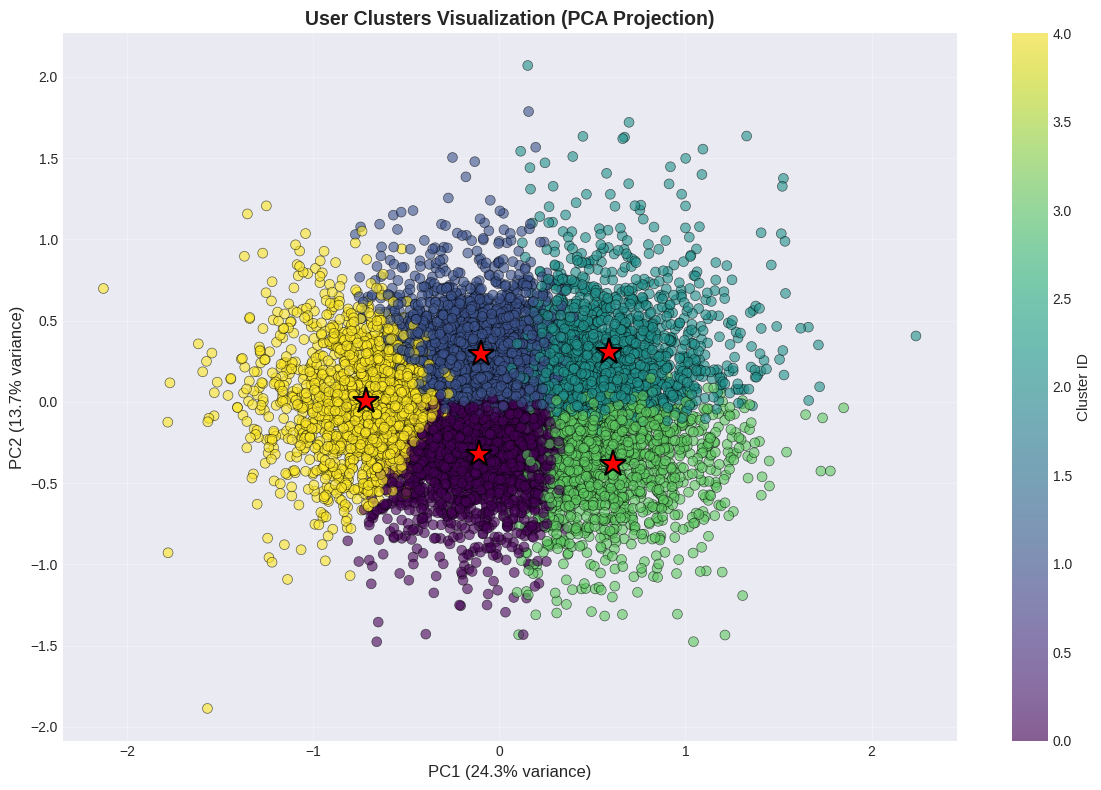


Cluster visualization complete!


In [27]:
def visualize_user_clusters(clustered_users, n_components=2):
    print(f"\nPreparing data for visualization")

    # Sample if dataset is too large
    sample_size = 10000
    total_users = clustered_users.count()

    if total_users > sample_size:
        sample_fraction = sample_size / total_users
        print(f"Sampling {sample_fraction * 100:.1f}% ({sample_size:,} users)")
        factors_sample = clustered_users.sample(False, sample_fraction, seed=42)
    else:
        print(f"Using all {total_users:,} users")
        factors_sample = clustered_users

    print("\nConverting to Pandas")
    factors_pd = factors_sample.toPandas()

    print("Extracting feature vectors")
    if hasattr(factors_pd['features'].iloc[0], 'toArray'):
        # If it's a DenseVector
        features_array = np.array([row.toArray() for row in factors_pd['features']])
    else:
        # If it's already a list or array
        features_array = np.array(factors_pd['features'].tolist())

    print(f"Feature matrix shape: {features_array.shape}")

    pca = PCA(n_components=n_components)
    features_2d = pca.fit_transform(features_array)

    explained_var = pca.explained_variance_ratio_
    print(f"PCA complete")
    print(f"PC1 explains {explained_var[0] * 100:.1f}% variance")
    print(f"PC2 explains {explained_var[1] * 100:.1f}% variance")
    print(f"Total explained: {sum(explained_var) * 100:.1f}%")

    print("\nCreating visualization")
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        features_2d[:, 0],
        features_2d[:, 1],
        c=factors_pd['cluster'],
        cmap='viridis',
        alpha=0.6,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )

    cbar = plt.colorbar(scatter, label='Cluster')
    cbar.set_label('Cluster ID', fontsize=11)

    plt.xlabel(f'PC1 ({explained_var[0] * 100:.1f}% variance)', fontsize=12)
    plt.ylabel(f'PC2 ({explained_var[1] * 100:.1f}% variance)', fontsize=12)
    plt.title('User Clusters Visualization (PCA Projection)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Add cluster centroids
    for cluster_id in factors_pd['cluster'].unique():
        cluster_points = features_2d[factors_pd['cluster'] == cluster_id]
        centroid = cluster_points.mean(axis=0)
        plt.plot(centroid[0], centroid[1], 'r*', markersize=20,
                 markeredgecolor='black', markeredgewidth=1.5)

    plt.tight_layout()
    plt.savefig('user_clusters_pca.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nCluster visualization complete!")


visualize_user_clusters(clustered_users)


Clustering configuration:
Number of clusters (k): 10
Algorithm: K-Means
Features: Latent factors from ALS

Initializing K-Means
Training K-Means model


Training complete in 6.77 seconds
CLUSTERING RESULTS
Within Set Sum of Squared Errors (WSSSE): 6607.07
CLUSTER DISTRIBUTION:


+-------+-----+
|cluster|count|
+-------+-----+
|      0| 1200|
|      1| 1068|
|      2| 1444|
|      3| 1100|
|      4|  921|
|      5| 1556|
|      6| 1705|
|      7| 1573|
|      8| 1425|
|      9| 1140|
+-------+-----+




Creating cluster distribution visualization


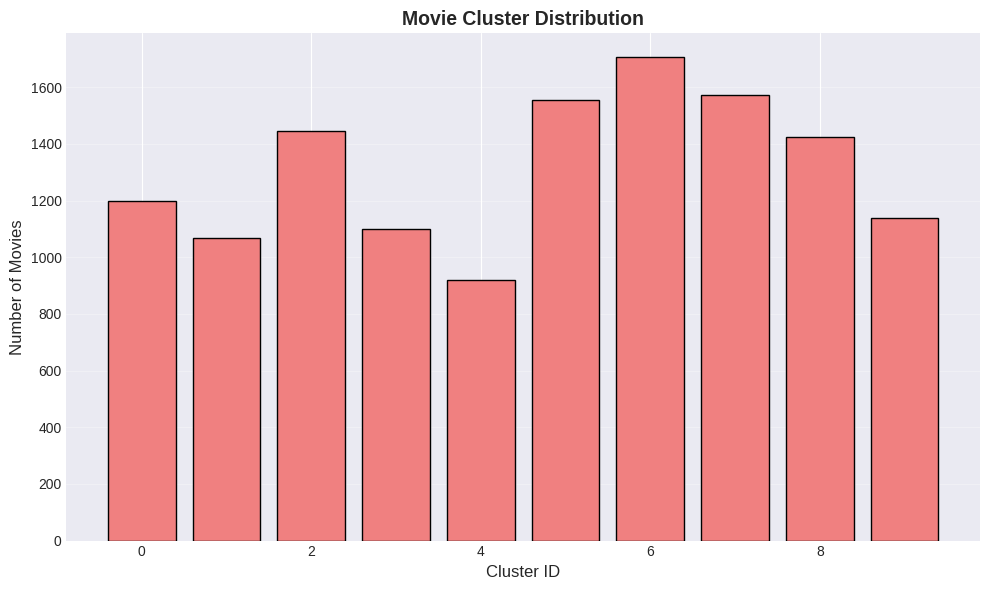


Movie clustering complete!

K-Means model stored in 'movie_kmeans'
Clustered movies stored in 'clustered_movies'


In [28]:
def cluster_movies(item_factors, k=10):
    print(f"\nClustering configuration:")
    print(f"Number of clusters (k): {k}")
    print(f"Algorithm: K-Means")
    print(f"Features: Latent factors from ALS")
    
    # Convert features to proper Vector type if needed
    from pyspark.ml.linalg import Vectors, VectorUDT
    from pyspark.sql.functions import udf
    from pyspark.sql.types import ArrayType
    
    feature_type = item_factors.schema['features'].dataType # Get feature column type
    
    if isinstance(feature_type, ArrayType):
        array_to_vector = udf(lambda arr: Vectors.dense(arr) if arr is not None else None, VectorUDT())
        item_factors = item_factors.withColumn('features', array_to_vector('features'))

    
    print("\nInitializing K-Means")
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol='features',
        predictionCol='cluster'
    )
    
    print("Training K-Means model")
    import time
    start_time = time.time()
    
    kmeans_model = kmeans.fit(item_factors)
    
    elapsed_time = time.time() - start_time
    print(f"Training complete in {elapsed_time:.2f} seconds")
    
    # Get cluster assignments
    clustered_movies = kmeans_model.transform(item_factors)
    
    # Compute WSSSE
    wssse = kmeans_model.summary.trainingCost
    
    print("CLUSTERING RESULTS")
    print(f"Within Set Sum of Squared Errors (WSSSE): {wssse:.2f}")
    
    # Show cluster distribution
    print("CLUSTER DISTRIBUTION:")
    cluster_dist = clustered_movies.groupBy('cluster').count().orderBy('cluster')
    cluster_dist.show()
    
    # Visualization
    cluster_dist_pd = cluster_dist.toPandas()
    
    print("\nCreating cluster distribution visualization")
    plt.figure(figsize=(10, 6))
    plt.bar(cluster_dist_pd['cluster'], cluster_dist_pd['count'], color='lightcoral', edgecolor='black')
    plt.xlabel('Cluster ID', fontsize=12)
    plt.ylabel('Number of Movies', fontsize=12)
    plt.title('Movie Cluster Distribution', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('movie_cluster_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nMovie clustering complete!")
    return kmeans_model, clustered_movies

movie_kmeans, clustered_movies = cluster_movies(item_factors, k=10)

print("\nK-Means model stored in 'movie_kmeans'")
print("Clustered movies stored in 'clustered_movies'")


Joining cluster assignments with training data
Data joined successfully

Computing cluster statistics
USER CLUSTER SUMMARY


+-------+-----------+------------------+---------+
|cluster|num_ratings|        avg_rating|num_users|
+-------+-----------+------------------+---------+
|      0|    3366398|3.5718487534747823|    33554|
|      1|    4092780| 3.533899696538783|    35285|
|      2|    1895523|  3.60542446596533|    22886|
|      3|    1310265|3.5941519463619955|    20166|
|      4|    3289492|3.4003095310765308|    26602|
+-------+-----------+------------------+---------+



DETAILED CLUSTER STATISTICS
Cluster           Users         Ratings      Avg Rating
0                33,554       3,366,398            3.57
1                35,285       4,092,780            3.53
2                22,886       1,895,523            3.61
3                20,166       1,310,265            3.59
4                26,602       3,289,492            3.40

Creating cluster analysis visualizations


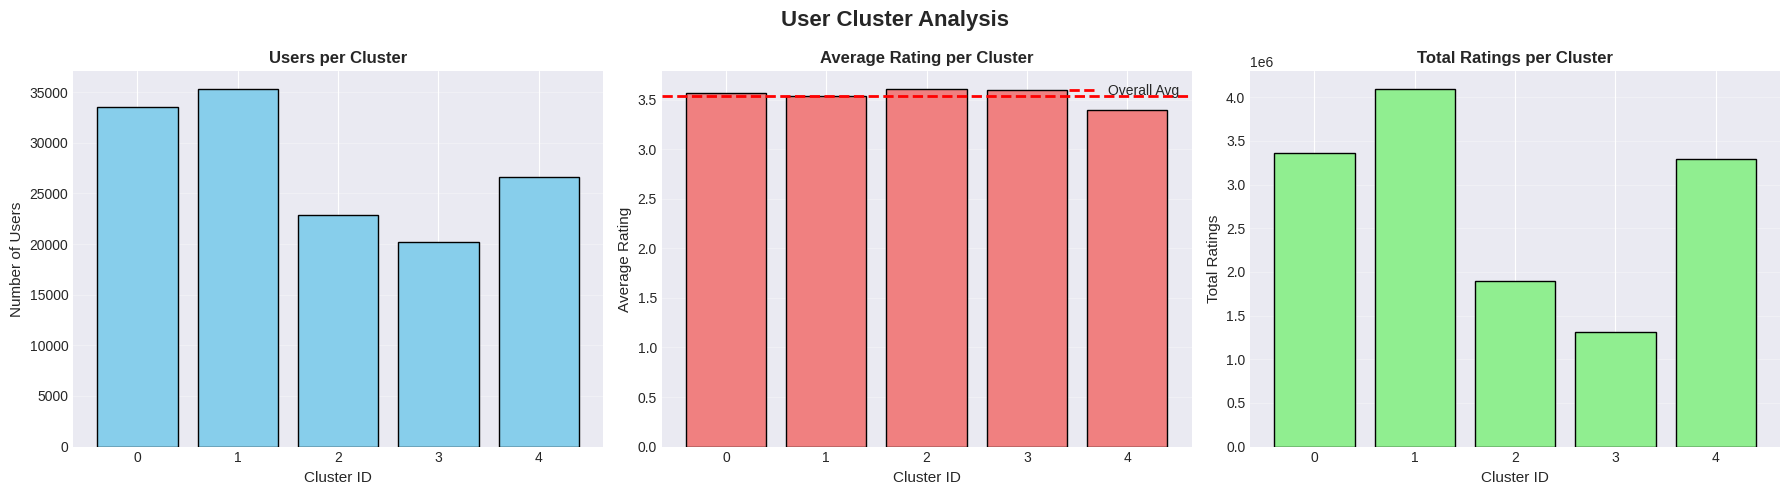


User cluster analysis complete!

Summary stored in 'user_cluster_summary'


In [29]:
def analyze_user_clusters(clustered_users, train_df):
    print("\nJoining cluster assignments with training data")

    # Join with original ratings to get statistics
    cluster_stats = train_df.join(
        clustered_users.select('id', 'cluster'),
        train_df.userId == clustered_users.id,
        'inner'
    )

    print("Data joined successfully")

    print("\nComputing cluster statistics")
    # Compute statistics per cluster
    cluster_summary = cluster_stats.groupBy('cluster').agg(
        count('rating').alias('num_ratings'),
        avg('rating').alias('avg_rating'),
        expr('count(distinct userId)').alias('num_users')
    ).orderBy('cluster')

    print("USER CLUSTER SUMMARY")
    cluster_summary.show()

    # Convert to Pandas for detailed analysis
    cluster_summary_pd = cluster_summary.toPandas()

    print("DETAILED CLUSTER STATISTICS")
    print(f"{'Cluster':<10} {'Users':>12} {'Ratings':>15} {'Avg Rating':>15}")
    for _, row in cluster_summary_pd.iterrows():
        print(f"{int(row['cluster']):<10} {int(row['num_users']):>12,} "
              f"{int(row['num_ratings']):>15,} {row['avg_rating']:>15.2f}")

    # Visualize cluster characteristics
    print("\nCreating cluster analysis visualizations")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('User Cluster Analysis', fontsize=16, fontweight='bold')

    # Plot 1: Users per cluster
    axes[0].bar(cluster_summary_pd['cluster'], cluster_summary_pd['num_users'],
                color='skyblue', edgecolor='black')
    axes[0].set_xlabel('Cluster ID', fontsize=11)
    axes[0].set_ylabel('Number of Users', fontsize=11)
    axes[0].set_title('Users per Cluster', fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')

    # Plot 2: Average rating per cluster
    axes[1].bar(cluster_summary_pd['cluster'], cluster_summary_pd['avg_rating'],
                color='lightcoral', edgecolor='black')
    axes[1].set_xlabel('Cluster ID', fontsize=11)
    axes[1].set_ylabel('Average Rating', fontsize=11)
    axes[1].set_title('Average Rating per Cluster', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].axhline(y=cluster_summary_pd['avg_rating'].mean(), color='red',
                    linestyle='--', linewidth=2, label='Overall Avg')
    axes[1].legend()

    # Plot 3: Total ratings per cluster
    axes[2].bar(cluster_summary_pd['cluster'], cluster_summary_pd['num_ratings'],
                color='lightgreen', edgecolor='black')
    axes[2].set_xlabel('Cluster ID', fontsize=11)
    axes[2].set_ylabel('Total Ratings', fontsize=11)
    axes[2].set_title('Total Ratings per Cluster', fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('user_cluster_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nUser cluster analysis complete!")
    return cluster_summary


user_cluster_summary = analyze_user_clusters(clustered_users, train_df)

print("\nSummary stored in 'user_cluster_summary'")


Joining all data
MOVIE CLUSTER SUMMARY


+-------+----------+------------------+------------------+
|cluster|num_movies|cluster_avg_rating|   avg_num_ratings|
+-------+----------+------------------+------------------+
|      0|      1200| 3.513399221597716|405.26916666666665|
|      1|      1068|2.6712236465778756| 781.8895131086142|
|      2|      1444| 3.410208337318808|1599.3324099722993|
|      3|      1100|2.3775249142282218| 592.9927272727273|
|      4|       921|2.9872457291744174| 371.4343105320304|
|      5|      1556|3.0826551924094416| 1337.318766066838|
|      6|      1705|3.6050389901839375|1690.1313782991203|
|      7|      1573| 3.640826954725765| 808.5244755244755|
|      8|      1425|3.3028610434736505|  402.218947368421|
|      9|      1140|3.2929942402440395| 2210.563157894737|
+-------+----------+------------------+------------------+

DOMINANT GENRES PER CLUSTER (Top 3):


+-------+---------+-----+----+
|cluster|genre    |count|rank|
+-------+---------+-----+----+
|0      |Drama    |930  |1   |
|0      |Comedy   |260  |2   |
|0      |Romance  |154  |3   |
|1      |Comedy   |707  |1   |
|1      |Drama    |296  |2   |
|1      |Romance  |293  |3   |
|2      |Drama    |827  |1   |
|2      |Comedy   |567  |2   |
|2      |Romance  |414  |3   |
|3      |Comedy   |431  |1   |
|3      |Horror   |408  |2   |
|3      |Thriller |301  |3   |
|4      |Horror   |478  |1   |
|4      |Thriller |254  |2   |
|4      |Comedy   |248  |3   |
|5      |Drama    |753  |1   |
|5      |Thriller |604  |2   |
|5      |Action   |514  |3   |
|6      |Drama    |1050 |1   |
|6      |Comedy   |470  |2   |
|6      |Thriller |395  |3   |
|7      |Drama    |968  |1   |
|7      |Comedy   |369  |2   |
|7      |Romance  |286  |3   |
|8      |Drama    |1022 |1   |
|8      |Comedy   |481  |2   |
|8      |Romance  |387  |3   |
|9      |Comedy   |558  |1   |
|9      |Action   |431  |2   |
|9      

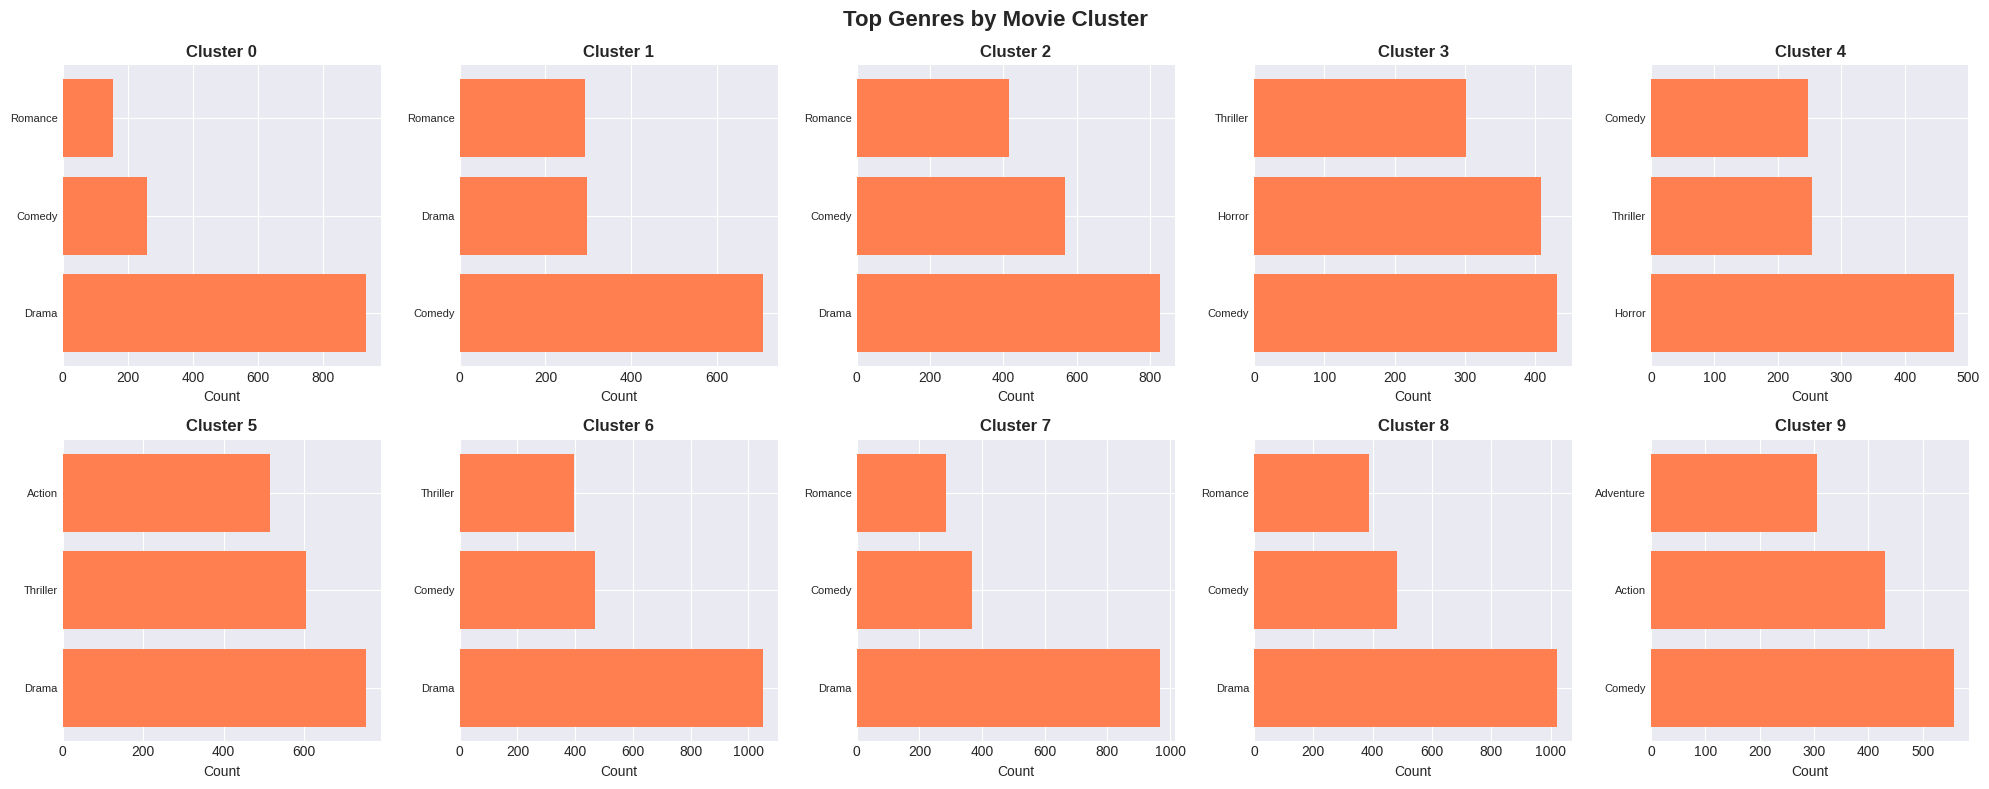


Movie cluster analysis complete!

Summary stored in 'movie_cluster_summary'


In [30]:
def analyze_movie_clusters(clustered_movies, movies_df, train_df):
    
    # Join with movie metadata
    cluster_movies_meta = clustered_movies.select('id', 'cluster').join(
        movies_df,
        clustered_movies.id == movies_df.movieId,
        'inner'
    )
    
    
    # Get rating statistics
    movie_stats = train_df.groupBy('movieId').agg(
        count('rating').alias('num_ratings'),
        avg('rating').alias('avg_rating')
    )
    
    print("\nJoining all data")
    cluster_movies_stats = cluster_movies_meta.join(
        movie_stats,
        cluster_movies_meta.movieId == movie_stats.movieId,
        'inner'
    )
    
    # Cluster summary - use qualified column names to avoid ambiguity
    cluster_summary = cluster_movies_stats.groupBy('cluster').agg(
        count(cluster_movies_meta.movieId).alias('num_movies'),
        avg('avg_rating').alias('cluster_avg_rating'),
        avg('num_ratings').alias('avg_num_ratings')
    ).orderBy('cluster')
    
    print("MOVIE CLUSTER SUMMARY")
    cluster_summary.show()
    
    # Find dominant genres per cluster
    if 'genres' in movies_df.columns:
        print("DOMINANT GENRES PER CLUSTER (Top 3):")
        
        cluster_genres = cluster_movies_meta.select('cluster', explode(split('genres', '\\|')).alias('genre'))
        genre_distribution = cluster_genres.groupBy('cluster', 'genre').count().orderBy('cluster', col('count').desc())
        
        # Show top 3 genres per cluster
        from pyspark.sql.window import Window
        from pyspark.sql.functions import row_number
        
        windowSpec = Window.partitionBy('cluster').orderBy(col('count').desc())
        top_genres = genre_distribution.withColumn('rank', row_number().over(windowSpec)) \
                                      .filter(col('rank') <= 3)
        
        top_genres.show(30, truncate=False)
        
        # Create genre distribution visualization for each cluster
        print("\nCreating genre distribution visualization")
        top_genres_pd = top_genres.toPandas()
        
        n_clusters = len(top_genres_pd['cluster'].unique())
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        fig.suptitle('Top Genres by Movie Cluster', fontsize=16, fontweight='bold')
        axes = axes.flatten()
        
        for cluster_id in range(min(n_clusters, 10)):
            cluster_data = top_genres_pd[top_genres_pd['cluster'] == cluster_id]
            if len(cluster_data) > 0:
                axes[cluster_id].barh(cluster_data['genre'], cluster_data['count'], color='coral')
                axes[cluster_id].set_title(f'Cluster {cluster_id}', fontweight='bold')
                axes[cluster_id].set_xlabel('Count')
                axes[cluster_id].tick_params(axis='y', labelsize=8)
        
        # Hide unused subplots
        for idx in range(n_clusters, 10):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig('movie_cluster_genres.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    print("\nMovie cluster analysis complete!")
    return cluster_summary

movie_cluster_summary = analyze_movie_clusters(clustered_movies, movies_df, train_df)

print("\nSummary stored in 'movie_cluster_summary'")


In [32]:
def get_user_recommendations(model, user_id, n=10, movies_df=None):
    print(f"\nGenerating recommendations for User {user_id}")
    print(f"Number of recommendations: {n}")

    user_df = spark.createDataFrame([(user_id,)], ["userId"])
    recommendations = model.recommendForUserSubset(user_df, n)

    print("Recommendations generated")

    # Extract recommendations
    recs_exploded = recommendations.select('userId', explode('recommendations').alias('rec'))
    recs_final = recs_exploded.select(
        'userId',
        col('rec.movieId').alias('movieId'),
        col('rec.rating').alias('predicted_rating')
    )

    print(f"TOP {n} RECOMMENDATIONS FOR USER {user_id}:")

    if movies_df is not None:
        # Join with movie titles
        recs_with_titles = recs_final.join(movies_df, on='movieId', how='left')
        recs_with_titles.select('movieId', 'title', 'genres', 'predicted_rating').show(n, truncate=False)
        return recs_with_titles
    else:
        recs_final.show(n, truncate=False)
        return recs_final


# Example: Get recommendations for user 1
user_recs = get_user_recommendations(model, user_id=1, n=10, movies_df=movies_df)

print("\nRecommendations stored in 'user_recs'")


Generating recommendations for User 1
Number of recommendations: 10
Recommendations generated
TOP 10 RECOMMENDATIONS FOR USER 1:


+-------+------------------------------------------------------------------------------+------------------------------+----------------+
|movieId|title                                                                         |genres                        |predicted_rating|
+-------+------------------------------------------------------------------------------+------------------------------+----------------+
|93006  |Very Potter Musical, A (2009)                                                 |Comedy|Musical                |4.2279153       |
|4993   |Lord of the Rings: The Fellowship of the Ring, The (2001)                     |Adventure|Fantasy             |4.212886        |
|7153   |Lord of the Rings: The Return of the King, The (2003)                         |Action|Adventure|Drama|Fantasy|4.2084136       |
|5952   |Lord of the Rings: The Two Towers, The (2002)                                 |Adventure|Fantasy             |4.198015        |
|260    |Star Wars: Episode IV - A New Ho